# Analysis of the imaging experiment
mouse name: 067 (or 057?)  
task: NearFarLong  
experimentalist: Snezana Raus-Balind  

### 1. Load the necessary object class
We use a custom-made class, ImagingSessionData, that will contain all behavioral and imaging data

In [1]:
from mousse.image_session_data import ImagingSessionData

### 2. Tell python where the data is
The required file structure is the following:  
- All data should be in the data folder
- Within the data folder separate subfolders are needed for each mouse. Folder name starts with the **name** of the mouse.
- For each mouse there should be at least two folders: one for the **imaging** data and one for the **behavioral** data.
- The behavioral folder is named as `MouseName_TaskName` - so we need a separate folder for each different task
- The behavioral log files are in separate subfolders named by the experiment's start time within the behavioral folder - e.g. `2021-02-03_10-15-50`
- The imaging folder is named as `MouseName_imaging`
- The suite2p imaging files are also in separate folders for each experiment below the imaging folder. 

In [2]:
datapath = os.getcwd() + '/' #current working directory - look for data and strings here!
date_time = '2021-10-31_10-31-32' # date and time of the imaging session
name = 'KS030' # mouse name
task = 'NearFarLong' # task name

## locate the suite2p folder
suite2p_folder = datapath + 'data/' + name + '_imaging/KS030_103121/'

## the name and location of the imaging log file
imaging_logfile_name = suite2p_folder + 'KS030_TSeries-10312021-1017-001.xml'

## the name and location of the trigger voltage file
TRIGGER_VOLTAGE_FILENAME = suite2p_folder + 'KS030_TSeries-10312021-1017-001_Cycle00001_VoltageRecording_001.csv'

### 3. Load all the data - this takes ~20 secs in my computer
Python looks for the data in the specified folders. It loads the behavioral data (position, lick and rewards) as well as the imaging data. It calculates the activity of the cells as a function of position in the different corridors and calculates their spatial tuning measures and corridor selectivity.  
The name of the object that contains all the data is `D1` here - Data 1.

In [ ]:
# 3. load all the data - this taks ~20 secs in my computer
D1 = ImagingSessionData(datapath, date_time, name, task, suite2p_folder, imaging_logfile_name, TRIGGER_VOLTAGE_FILENAME)#, startendlap=[27, 99])


Error evaluating: thread_id: pid_17640_id_2311922111888
frame_id: 2311256551680
scope: FRAME
attrs: self	corridor_list	corridors	00	reward_zone_ends
Traceback (most recent call last):
  File "C:\Program Files\JetBrains\PyCharm 2025.3.1.1\plugins\python-ce\helpers\pydev\_pydevd_bundle\pydevd_vars.py", line 316, in resolve_compound_variable_fields
    return _typeName, _resolve_default_variable_fields(var, resolver, offset)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\JetBrains\PyCharm 2025.3.1.1\plugins\python-ce\helpers\pydev\_pydevd_bundle\pydevd_vars.py", line 266, in _resolve_default_variable_fields
    return resolver.get_dictionary(VariableWithOffset(var, offset) if offset else var)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\JetBrains\PyCharm 2025.3.1.1\plugins\python-ce\helpers\pydev\pydevd_plugins\extensions\types\pydevd_plugin_numpy_types.py", line 95, 

The behavior is divided into laps (trials or runs). You can check the **number of laps** and which lap is associated with imaging data in the following way:

In [4]:
print(D1.n_laps)
print(D1.i_Laps_ImData)

134
[ 42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59
  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77
  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95
  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113
 114 115 116]


So we have 229 laps and laps 83-138 contain imaging data.  
### 4. Plotting the behavioral data
You can plot the behavioral data of the session:

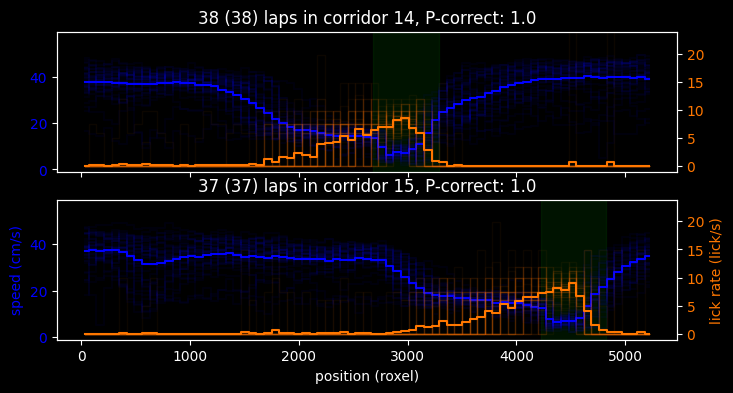

In [5]:
#D1.plot_session()
D1.plot_session(selected_laps=D1.i_Laps_ImData)

### 5. Plot the ratemaps
First, we plot the ratemaps of some neurons. There are several options - selecting the cells, sorting and normalising the ratemaps.
- selection: here we select all active cells (activity in at least 20% of laps), but any other selection criteria 
- sorting: place fields can be sorted by either corridors
- place cells can be normalised - so the peak has the same height

In [6]:
D1.ratemaps[1].shape

(75, 1367)

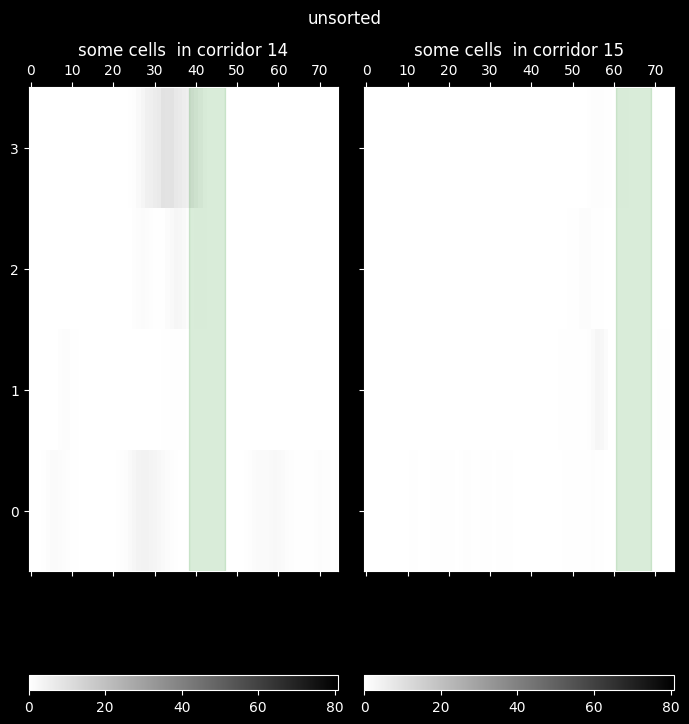

array([0, 1, 2, 3])

In [7]:
cellids = np.arange(4)
D1.plot_ratemaps(cellids = cellids, sorted=False, normalized=False)

### 6. Plot the spatial properies of the neurons

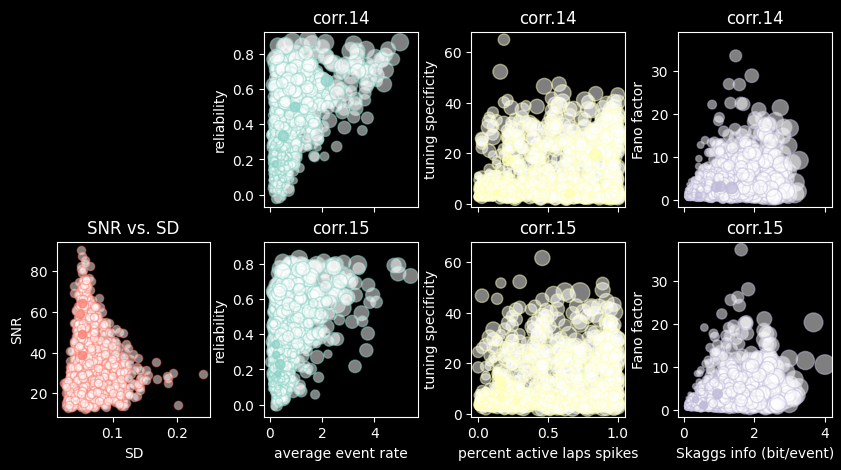

In [8]:
D1.plot_properties(cellids=cellids, interactive=False)

### 7. Calculate significance of tuning by shuffling the imaging data 

In [9]:
D1.calc_shuffle(cellids, 1000, 'shift')

C:\dev\abmice/data/KS030_imaging/KS030_103121/analysed_data/shuffle_stats_n1000_mode_shift.csv successfully loaded


In [10]:
D1.shuffle_Pvalues

array([[0.00e+00, 0.00e+00, 6.00e-03, 3.20e-01, 1.13e-01, 0.00e+00,
        1.39e-01, 0.00e+00, 1.12e-01, 0.00e+00, 0.00e+00],
       [1.00e+00, 4.47e-01, 1.01e-01, 4.17e-01, 3.20e-02, 2.90e-02,
        0.00e+00, 1.49e-01, 7.28e-01, 0.00e+00, 0.00e+00],
       [2.00e+00, 2.00e-03, 4.11e-01, 9.00e-03, 2.70e-02, 0.00e+00,
        0.00e+00, 9.60e-02, 6.89e-01, 1.00e+00, 0.00e+00],
       [3.00e+00, 0.00e+00, 1.80e-02, 1.00e-03, 4.80e-02, 0.00e+00,
        0.00e+00, 0.00e+00, 9.43e-01, 1.00e+00, 0.00e+00]])

### 6.  Plot the activity lap by lap
We can also plot the lap by lap activity of a selected cell. Again, there are several options, but the simplest is to plot the rate as a function of position.

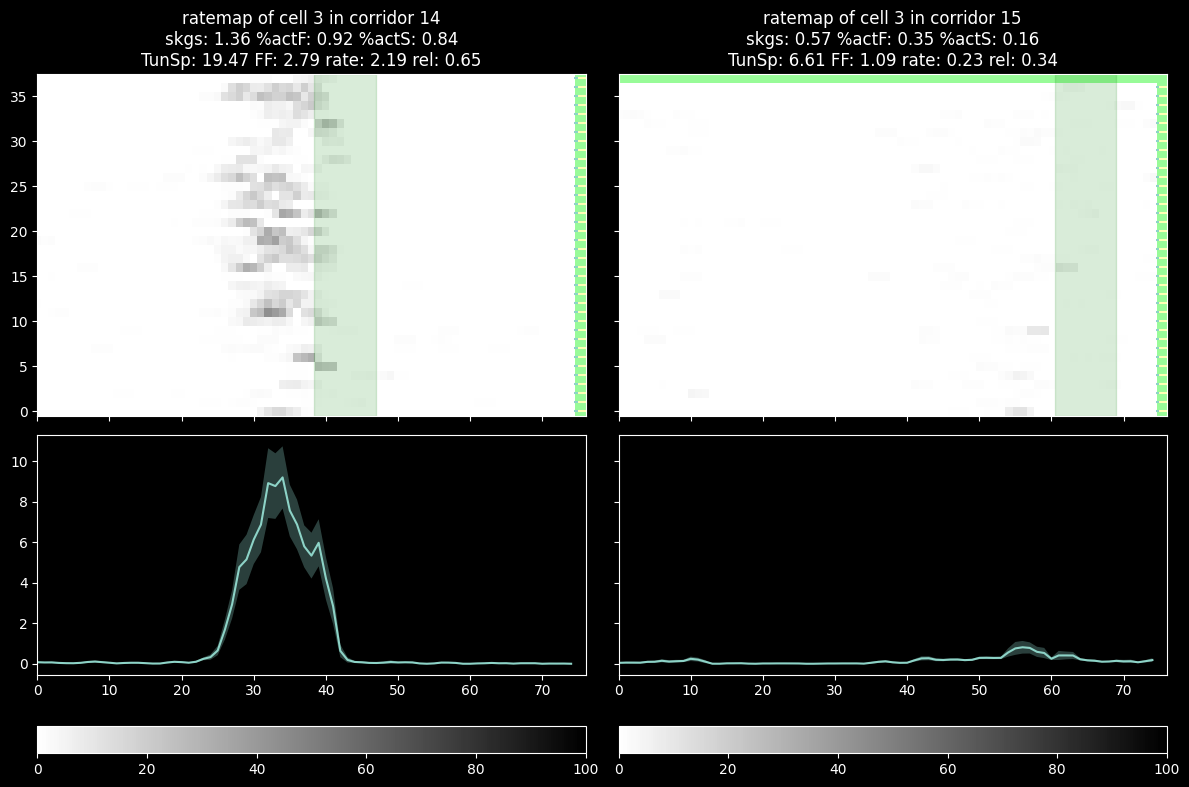

In [11]:
D1.plot_cell_laps(cellid=3, signal='rate') ## look at lap 20

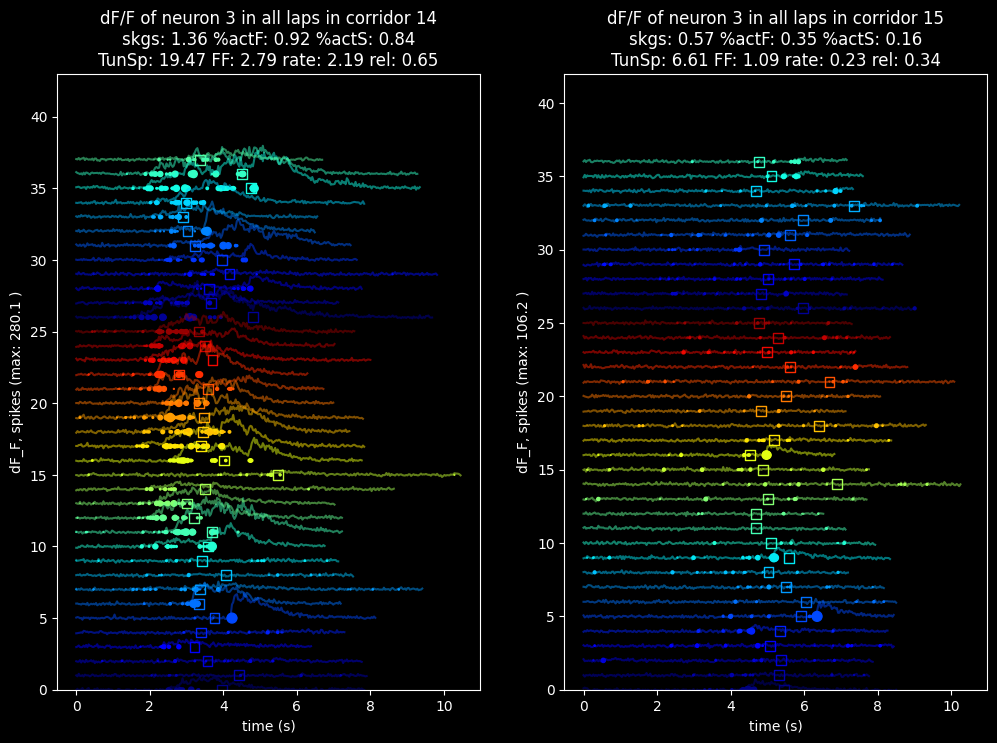

In [12]:
D1.plot_cell_laps(cellid=3, signal='dF') ## look at lap 20